# Explain UFR4: Focused-Time Inflation In TOPS Vs Stripmap

## Navigation

- [Overall](./derive_main.md)
- Companion notebook: [Explain UFR3](./explain_ufr3.ipynb)
- Related notes:
  - [Azimuth Compression](./azimuth_compression.md)
  - [Azimuth Time Folding](./azimuth_time_folding.md)
  - [Azimuth Time UFR](./azimuth_time_ufr.md)

## Summary

- 這份 notebook 直接以 `explain_UFR4.py` 的兩個 demo case 為主體，改寫成像 `explain_ufr3.ipynb` 那樣的教學型 stage-by-stage notebook。
- 每個 stage 都先跑一個 code block 產生當前結果，再接一段對應的 `Result / Mathematical Step / Physical Meaning / Fully Expanded Closed Form`。
- 核心比較只有一件事：`t_{\mathrm{expo}} = t_c` 和 `t_{\mathrm{expo}} = \frac{k_a}{k_a-k_s} t_c` 這兩種 exposure geometry，為什麼會導致不同的 focused-time span。

## Problem Definition

本 notebook 要回答三件事：

1. `simulate_latex_ufr()` 和 `simulate_scan_latex_ufr()` 的數學模型分別是什麼。
2. 在 matched filter 相同的前提下，為什麼 raw exposure center 的 mapping 會改變聚焦後的時間支撐。
3. 為什麼這個支撐伸長就是後續 time folding / time UFR 要處理的根源。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0b1020'
plt.rcParams['axes.facecolor'] = '#0b1020'
plt.rcParams['savefig.facecolor'] = '#0b1020'
plt.rcParams['axes.edgecolor'] = '#8aa1c1'
plt.rcParams['axes.labelcolor'] = '#d7e3f4'
plt.rcParams['text.color'] = '#eef4ff'
plt.rcParams['xtick.color'] = '#c9d5e6'
plt.rcParams['ytick.color'] = '#c9d5e6'
plt.rcParams['grid.color'] = '#334155'


def build_case(PRF, T_burst, Naz, ks, ka, T_dwell, tc_array, exposure_fn):
    eta = np.linspace(-T_burst / 2, T_burst / 2, Naz, endpoint=False)
    raw_signal = np.zeros(Naz, dtype=complex)
    expo_centers = []

    for tc in tc_array:
        t_expo = exposure_fn(tc)
        expo_centers.append(t_expo)
        window = np.abs(eta - t_expo) <= (T_dwell / 2)
        target_phase = np.exp(1j * np.pi * ka * (eta - tc) ** 2)
        raw_signal[window] += target_phase[window]

    S1 = np.fft.fftshift(np.fft.fft(raw_signal))
    f_eta = np.linspace(-PRF / 2, PRF / 2, Naz, endpoint=False)
    H_az = np.exp(1j * np.pi * (1.0 / ka) * f_eta**2)
    s_final = np.fft.ifft(np.fft.ifftshift(S1 * H_az))

    return {
        'PRF': PRF,
        'T_burst': T_burst,
        'Naz': Naz,
        'ks': ks,
        'ka': ka,
        'T_dwell': T_dwell,
        'tc_array': tc_array,
        'expo_centers': np.array(expo_centers),
        'eta': eta,
        'f_eta': f_eta,
        'raw_signal': raw_signal,
        'S1': S1,
        'H_az': H_az,
        's_final': s_final,
    }


def plot_tf_view(signal_like, fs, title, y_limit, is_time_input=False, nfft=256, noverlap=200, cmap='turbo'):
    if is_time_input:
        time_sig = signal_like
    else:
        time_sig = np.fft.ifft(np.fft.ifftshift(signal_like))

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.specgram(time_sig, NFFT=nfft, Fs=fs, noverlap=noverlap, cmap=cmap, scale='linear')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Slow Time [eta] (s)')
    ax.set_ylabel('Doppler Freq [f_eta] (Hz)')
    ax.set_ylim(-y_limit, y_limit)
    fig.tight_layout()
    return fig


/home/hsuyueh.chuang/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
PRF = 1000.0
T_burst = 4.0
Naz = int(PRF * T_burst)
ka = -500.0
T_dwell = 0.3
tc_array = np.linspace(-3.5, 3.5, 40)

case_A = build_case(
    PRF=PRF,
    T_burst=T_burst,
    Naz=Naz,
    ks=700.0,
    ka=ka,
    T_dwell=T_dwell,
    tc_array=tc_array,
    exposure_fn=lambda tc: 1.0 * tc,
)

case_B = build_case(
    PRF=PRF,
    T_burst=T_burst,
    Naz=Naz,
    ks=100.0,
    ka=ka,
    T_dwell=T_dwell,
    tc_array=tc_array,
    exposure_fn=lambda tc: (ka / (ka - 100.0)) * tc,
)

print(f'Naz = {Naz}, PRF = {PRF:.0f} Hz, T_burst = {T_burst:.1f} s')
print(f'Case A: ks = {case_A["ks"]:.1f} Hz/s, ka = {case_A["ka"]:.1f} Hz/s, T_dwell = {case_A["T_dwell"]:.2f} s')
print(f'Case B: ks = {case_B["ks"]:.1f} Hz/s, ka = {case_B["ka"]:.1f} Hz/s, T_dwell = {case_B["T_dwell"]:.2f} s')


Naz = 4000, PRF = 1000 Hz, T_burst = 4.0 s
Case A: ks = 700.0 Hz/s, ka = -500.0 Hz/s, T_dwell = 0.30 s
Case B: ks = 100.0 Hz/s, ka = -500.0 Hz/s, T_dwell = 0.30 s


## Symbols And Assumptions

- $\eta$: azimuth slow time
- $f_\eta$: azimuth frequency
- $T_{\mathrm{burst}}$: burst duration
- $\mathrm{PRF}$: azimuth sampling rate
- $N_{\mathrm{az}} = \mathrm{PRF} \cdot T_{\mathrm{burst}}$
- $k_a$: target azimuth FM rate
- $k_s$: scan-induced Doppler-centroid rate
- $T_{\mathrm{dwell}}$: illumination dwell time
- $t_c$: target focus-center label
- $t_{\mathrm{expo}}$: target exposure center
- $H_{\mathrm{az}}(f_\eta)=\exp\left(j\pi \frac{f_\eta^2}{k_a}\right)$: azimuth matched filter


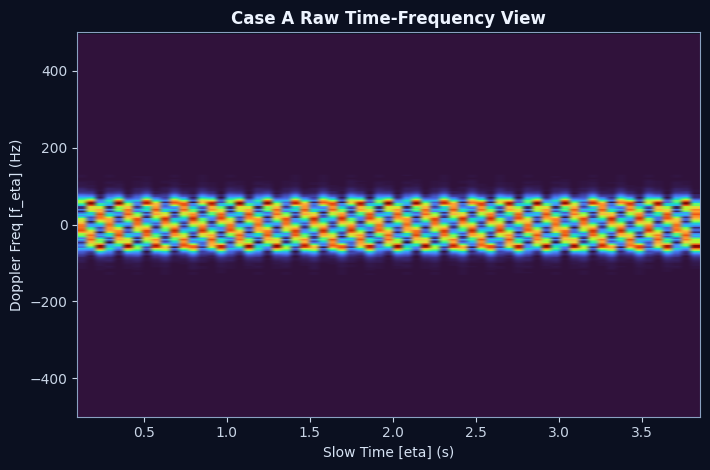

In [3]:
fig = plot_tf_view(
    case_A['raw_signal'],
    case_A['PRF'],
    'Case A Raw Time-Frequency View',
    case_A['PRF'] / 2,
    is_time_input=True,
)
plt.show()


## 1. Case A Raw Stage

Result:

這個 block 直接把 `simulate_latex_ufr()` 的 raw stage 跑出來。你看到的三件事是同一個 stage 的三個投影：raw magnitude、它的 $S_1(f_\eta)$ 頻域 magnitude、以及 raw time-frequency view。

Mathematical Step:

$$
t_{\mathrm{expo},p}=t_{c,p}
$$

$$
s_{\mathrm{raw},A,p}(\eta)=
\mathrm{rect}\left(\frac{\eta-t_{c,p}}{T_{\mathrm{dwell}}}\right)
\exp\left(j\pi k_a(\eta-t_{c,p})^2\right)
$$

$$
s_{\mathrm{raw},A}(\eta)=
\sum_p
\mathrm{rect}\left(\frac{\eta-t_{c,p}}{T_{\mathrm{dwell}}}\right)
\exp\left(j\pi k_a(\eta-t_{c,p})^2\right)
$$

$$
S_{1,A}(f_\eta)=\mathcal{F}_\eta\left[s_{\mathrm{raw},A}(\eta)\right]
$$

Physical Meaning:

Case A 的曝光中心就是目標最後的 focus-center。本質上這是 stripmap-like baseline：每個 target 在 raw burst 中被看見的時刻，和之後應該壓縮回去的位置是一致的，所以這裡還看不到幾何伸長。

Fully Expanded Closed Form:

$$
s_{\mathrm{raw},A}(\eta)=
\sum_p
\mathrm{rect}\left(\frac{\eta-t_{c,p}}{T_{\mathrm{dwell}}}\right)
\exp\left(j\pi k_a(\eta-t_{c,p})^2\right)
$$


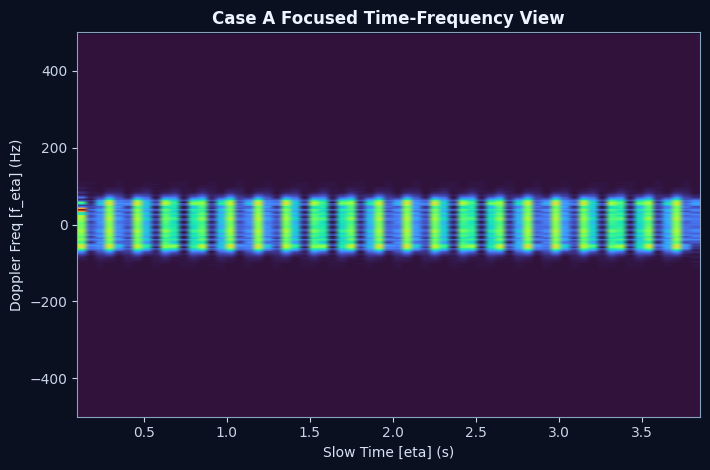

In [4]:
fig = plot_tf_view(
    case_A['s_final'],
    case_A['PRF'],
    'Case A Focused Time-Frequency View',
    case_A['PRF'] / 2,
    is_time_input=True,
)
plt.show()


## 2. Case A Focused Stage

Result:

這個 block 顯示同一個 raw geometry 經過 `H_{\mathrm{az}}(f_\eta)` 後的 focused output。Case A 會正常壓縮，而且主能量仍然沿著 `t_c` 的排列回來。

Mathematical Step:

$$
H_{\mathrm{az}}(f_\eta)=\exp\left(j\pi\frac{f_\eta^2}{k_a}\right)
$$

$$
s_{\mathrm{final},A}(\eta)=\mathcal{F}^{-1}_\eta\left[S_{1,A}(f_\eta)H_{\mathrm{az}}(f_\eta)\right]
$$

$$
s_{\mathrm{final},A}(\eta)\approx
\sum_p A_{A,p}\,\mathrm{sinc}\left(B_{A,p}(\eta-t_{c,p})\right)\exp\left(j\phi_{A,p}\right)
$$

Physical Meaning:

這一步不是只說「可以聚焦」，而是說聚焦之後的時間支撐沒有被額外拉長。也就是說，Case A 提供的是不含 focused-time inflation 的參考答案。

Fully Expanded Closed Form:

$$
s_{\mathrm{final},A}(\eta)\approx
\sum_p A_{A,p}\,\mathrm{sinc}\left(B_{A,p}(\eta-t_{c,p})\right)\exp\left(j\phi_{A,p}\right)
$$


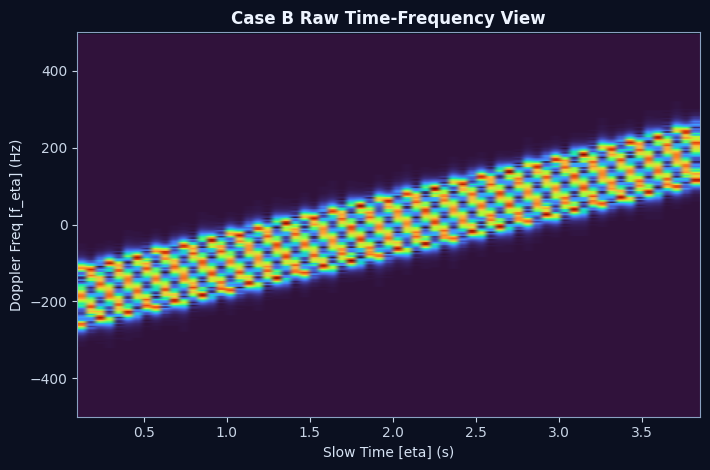

In [5]:
fig = plot_tf_view(
    case_B['raw_signal'],
    case_B['PRF'],
    'Case B Raw Time-Frequency View',
    case_B['PRF'] / 2,
    is_time_input=True,
)
plt.show()


## 3. Case B Raw Stage

Result:

這個 block 對應 `simulate_scan_latex_ufr()` 的 raw stage。圖上最關鍵的差異不是 chirp 本身變了，而是 raw illumination window 的中心已經不再和 `t_c` 重合。

Mathematical Step:

$$
t_{\mathrm{expo},p}=\frac{k_a}{k_a-k_s}t_{c,p}
$$

$$
s_{\mathrm{raw},B}(\eta)=
\sum_p
\mathrm{rect}\left(\frac{\eta-\frac{k_a}{k_a-k_s}t_{c,p}}{T_{\mathrm{dwell}}}\right)
\exp\left(j\pi k_a(\eta-t_{c,p})^2\right)
$$

$$
S_{1,B}(f_\eta)=\mathcal{F}_\eta\left[s_{\mathrm{raw},B}(\eta)\right]
$$

Physical Meaning:

Case B 改變的不是 matched filter，而是曝光幾何。目標被照亮的時刻先被 scan-induced geometry 推到 `t_{\mathrm{expo}}`，這意味著 raw burst window 之後映到 focused domain 時，天然就帶著一個比例伸縮。

Fully Expanded Closed Form:

$$
s_{\mathrm{raw},B}(\eta)=
\sum_p
\mathrm{rect}\left(\frac{\eta-\frac{k_a}{k_a-k_s}t_{c,p}}{T_{\mathrm{dwell}}}\right)
\exp\left(j\pi k_a(\eta-t_{c,p})^2\right)
$$


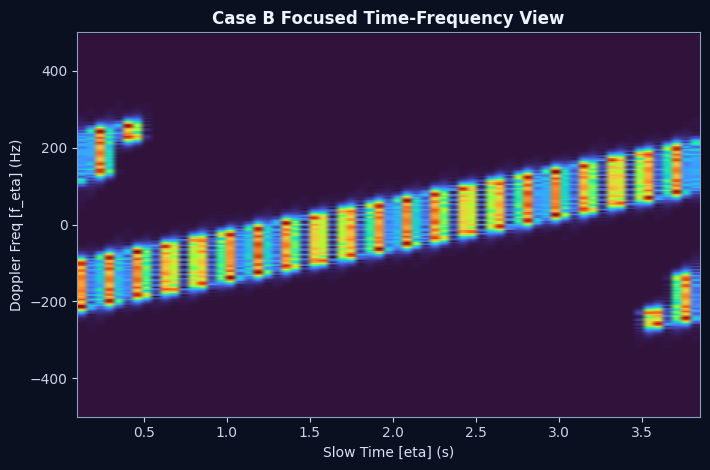

In [6]:
fig = plot_tf_view(
    case_B['s_final'],
    case_B['PRF'],
    'Case B Focused Time-Frequency View',
    case_B['PRF'] / 2,
    is_time_input=True,
)
plt.show()


## 4. Case B Focused Stage

Result:

這個 block 顯示的是：就算 matched filter 和 Case A 完全相同，Case B 聚焦後的能量分布仍然會對應到比較長的 focused-time support。這就是 UFR4 要抓的現象本體。

Mathematical Step:

$$
s_{\mathrm{final},B}(\eta)=\mathcal{F}^{-1}_\eta\left[S_{1,B}(f_\eta)H_{\mathrm{az}}(f_\eta)\right]
$$

由 exposure mapping 反解可得

$$
t_{c,p}=\frac{k_a-k_s}{k_a}t_{\mathrm{expo},p}
$$

因此 stage-local focused signal 可寫成

$$
s_{\mathrm{final},B}(\eta)\approx
\sum_p A_{B,p}\,\mathrm{sinc}\left(B_{B,p}(\eta-t_{c,p})\right)\exp\left(j\phi_{B,p}\right),
\qquad t_{c,p}=\frac{k_a-k_s}{k_a}t_{\mathrm{expo},p}
$$

Physical Meaning:

TOPS-like case 不是無法聚焦，而是聚焦後的時間支撐會被 exposure-to-focus mapping 拉長。也就是說，focused-time inflation 不是後段處理意外造成的，而是 raw geometry 直接決定的結果。

Fully Expanded Closed Form:

$$
s_{\mathrm{final},B}(\eta)\approx
\sum_p A_{B,p}\,\mathrm{sinc}\left(B_{B,p}(\eta-t_{c,p})\right)\exp\left(j\phi_{B,p}\right),
\qquad t_{c,p}=\frac{k_a-k_s}{k_a}t_{\mathrm{expo},p}
$$


Case A focused-span factor: 1.000
Case B focused-span factor: 1.200


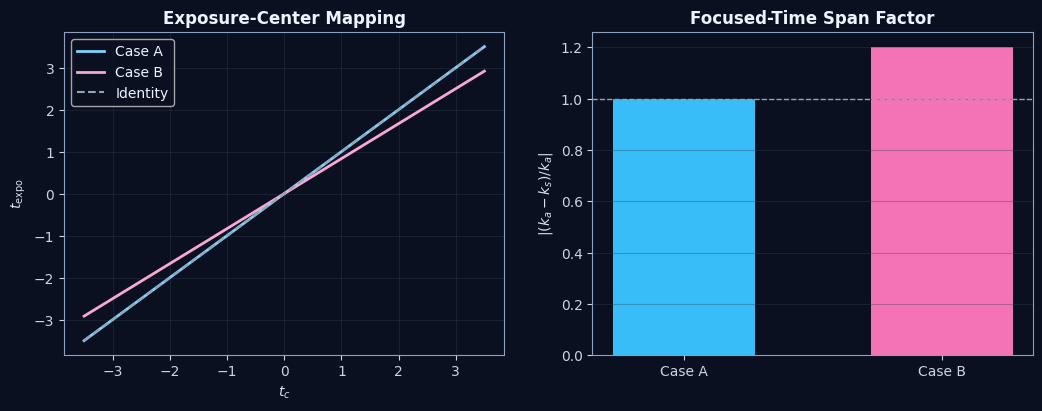

In [7]:
ratio_A = abs((case_A['ka'] - 0.0) / case_A['ka'])
ratio_B = abs((case_B['ka'] - case_B['ks']) / case_B['ka'])

print(f'Case A focused-span factor: {ratio_A:.3f}')
print(f'Case B focused-span factor: {ratio_B:.3f}')

fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.2))
axs[0].plot(case_A['tc_array'], case_A['expo_centers'], linewidth=2.0, color='#7dd3fc', label='Case A')
axs[0].plot(case_B['tc_array'], case_B['expo_centers'], linewidth=2.0, color='#f9a8d4', label='Case B')
axs[0].plot(case_A['tc_array'], case_A['tc_array'], '--', color='#94a3b8', label='Identity')
axs[0].set_title('Exposure-Center Mapping', fontsize=12, fontweight='bold')
axs[0].set_xlabel(r'$t_c$')
axs[0].set_ylabel(r'$t_{\mathrm{expo}}$')
axs[0].grid(True, alpha=0.35)
axs[0].legend(loc='best')

axs[1].bar(['Case A', 'Case B'], [ratio_A, ratio_B], color=['#38bdf8', '#f472b6'], width=0.55)
axs[1].axhline(1.0, color='#94a3b8', linestyle='--', linewidth=1.0)
axs[1].set_title('Focused-Time Span Factor', fontsize=12, fontweight='bold')
axs[1].set_ylabel(r'$| (k_a-k_s) / k_a |$')
axs[1].grid(True, axis='y', alpha=0.35)
plt.show()


## 5. Focused-Time Inflation Formula

Result:

最後這個 block 把前面兩個 case 的差異收成幾何公式。左圖是在看 `t_c \mapsto t_{\mathrm{expo}}` 的 mapping；右圖則直接把 focused-time span factor 畫出來。

Mathematical Step:

Case B 的 source-code 幾何為

$$
t_{\mathrm{expo}}=\frac{k_a}{k_a-k_s}t_c
$$

因此

$$
t_c=\frac{k_a-k_s}{k_a}t_{\mathrm{expo}}
$$

若 raw burst 的可見範圍滿足

$$
|t_{\mathrm{expo}}|\le \frac{T_{\mathrm{burst}}}{2}
$$

則 focused-time span 為

$$
T_{\mathrm{focused}}\approx\left|\frac{k_a-k_s}{k_a}\right|T_{\mathrm{burst}}
$$

對這個 notebook 的兩組參數：

$$
\text{Case A factor}=1,
\qquad
\text{Case B factor}=\left|\frac{-500-100}{-500}\right|=1.2
$$

Physical Meaning:

Case A 沒有 exposure-to-focus stretch，所以 focused span 和 burst duration 同階。Case B 則因為 `k_s` 造成 exposure center 與 focus center 之間的比例伸縮，讓聚焦後時間支撐被放大成 `1.2 T_{\mathrm{burst}}`。這就是後面 time folding / time UFR 必須出場的原因。

Fully Expanded Closed Form:

$$
s_{\mathrm{final},B}(\eta)\approx
\sum_p A_{B,p}\,\mathrm{sinc}\left(B_{B,p}(\eta-t_{c,p})\right)\exp\left(j\phi_{B,p}\right),
\qquad
|t_c|\le\left|\frac{k_a-k_s}{k_a}\right|\frac{T_{\mathrm{burst}}}{2}
$$


## Final Result

這份 [explain_ufr4.ipynb](/home/hsuyueh.chuang/Desktop/vscode/github/sar_tops_mode/derive/explain_ufr4.ipynb) 現在已經改成和 [explain_ufr3.ipynb](/home/hsuyueh.chuang/Desktop/vscode/github/sar_tops_mode/derive/explain_ufr3.ipynb) 同型的教學 notebook：每個 stage 先跑 code block 產生結果，再接對應的數學、結果解讀與物理意義。

核心結論是

$$
T_{\mathrm{focused}}\approx\left|\frac{k_a-k_s}{k_a}\right|T_{\mathrm{burst}}
$$

所以 `t_{\mathrm{expo}} = t_c` 對應不伸長的 baseline，而 `t_{\mathrm{expo}} = \frac{k_a}{k_a-k_s}t_c` 會把 focused-time span 拉長，這正是 UFR4 要說明的主題。
